In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import preprocessor as p
import nltk
import regex as re
from textblob import TextBlob
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
from nltk.corpus import stopwords
import os

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pices\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Read Dataset

In [2]:
# Menggabungkan semua data dari semua file CSV
dataset = pd.read_csv('D:/KULIAH/TA-DESAK/model/sampling_fix.csv')

In [3]:
# Menampilkan informasi tentang dataset gabungan
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14316 entries, 0 to 14315
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Title_Summary  14316 non-null  object
 1   Label          14316 non-null  object
dtypes: object(2)
memory usage: 223.8+ KB
None


In [4]:
dataset.sample(20)

,Title_Summary,Label
3454,Program JKN Bantu Djitmen Berobat dengan Mudah...,berlebihan
4335,"Terancam Kena Cancel Culture, Raffi Ahmad Jela...",relevan
3582,Personel Girl Grup Ini Beber Perlakuan Kasar D...,nonrelevan
4430,Kedekatan Roy Kiyoshi dan Evelyn Nada Anjani B...,nonrelevan
5951,Sadisnya Pembunuhan Gadis Penjual Gorengan di ...,relevan
5384,"Unggul 15 Gol Bukan Terbesar, Ini Kemenangan S...",berlebihan
1618,Peragaan Busana Mini Tampilkan Karya Desainer ...,nonrelevan
7071,Song Joong Ki dan Jang Dong Gun Bahas Drama Ba...,nonrelevan
9670,Sekjen PKS Sebut Sahroni Paham Peta Politik Ja...,nonrelevan
11420,Duka Melly Goeslaw untuk BJ Habibie: Bahagia B...,berlebihan


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14316 entries, 0 to 14315
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Title_Summary  14316 non-null  object
 1   Label          14316 non-null  object
dtypes: object(2)
memory usage: 223.8+ KB


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14316 entries, 0 to 14315
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Title_Summary  14316 non-null  object
 1   Label          14316 non-null  object
dtypes: object(2)
memory usage: 223.8+ KB


# Pre-Processing

## Delete data NaN

In [7]:
# Melihat unique value pada kolom "label"
dataset["Label"].unique()

array(['berlebihan', 'nonrelevan', 'relevan'], dtype=object)

In [8]:
# Hapus baris yang memiliki NaN di kolom "label"
df_cleaned = dataset.dropna(subset=["Label"])

In [9]:
# Melihat unique value pada kolom "label"
df_cleaned["Label"].unique()

array(['berlebihan', 'nonrelevan', 'relevan'], dtype=object)

In [10]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14316 entries, 0 to 14315
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Title_Summary  14316 non-null  object
 1   Label          14316 non-null  object
dtypes: object(2)
memory usage: 223.8+ KB


## Title

### Delete characters other than letters, numbers and spaces

In [11]:
df_cleaned.head(10)

,Title_Summary,Label
0,"Senada dengan JK, Ketua Komisi X Mengaku Sorot...",berlebihan
1,Foto Perdana Baby Arkana Anak Ketiga Nikita Mi...,nonrelevan
2,Ungkapan Hati Tora Sudiro Usai Nikahkan Anak P...,relevan
3,"Kenakan Gaun Mewah, Jennie BLACKPINK Justru Di...",nonrelevan
4,Nadhila QP Ungkap Rahasia Kecantikan Alami di ...,nonrelevan
5,Mpok Alpa Berbagi Kisah Masa Kecil di Kampung ...,nonrelevan
6,"Soal UU KPK, Ketua Kadin: Baik untuk Kepastian...",berlebihan
7,Penjelasan Fuji soal Gaji Eks Manajer Rp 500 R...,relevan
8,Kondisi Terkini Nunung Usai Jalani Operasi Mat...,relevan
9,"NasDem Gabung Pemerintahan Prabowo-Gibran, Beg...",berlebihan


In [12]:
df_cleaned['Title_Summary'] = df_cleaned['Title_Summary'].str.replace(r'[^a-zA-Z0-9\s]', ' ', regex=True)

In [13]:
df_cleaned.head(10)

,Title_Summary,Label
0,Senada dengan JK Ketua Komisi X Mengaku Sorot...,berlebihan
1,Foto Perdana Baby Arkana Anak Ketiga Nikita Mi...,nonrelevan
2,Ungkapan Hati Tora Sudiro Usai Nikahkan Anak P...,relevan
3,Kenakan Gaun Mewah Jennie BLACKPINK Justru Di...,nonrelevan
4,Nadhila QP Ungkap Rahasia Kecantikan Alami di ...,nonrelevan
5,Mpok Alpa Berbagi Kisah Masa Kecil di Kampung ...,nonrelevan
6,Soal UU KPK Ketua Kadin Baik untuk Kepastian...,berlebihan
7,Penjelasan Fuji soal Gaji Eks Manajer Rp 500 R...,relevan
8,Kondisi Terkini Nunung Usai Jalani Operasi Mat...,relevan
9,NasDem Gabung Pemerintahan Prabowo Gibran Beg...,berlebihan


### Lowercase

In [14]:
df_cleaned['Title_Summary'] = df_cleaned['Title_Summary'].str.lower()
df_cleaned.head()

,Title_Summary,Label
0,senada dengan jk ketua komisi x mengaku sorot...,berlebihan
1,foto perdana baby arkana anak ketiga nikita mi...,nonrelevan
2,ungkapan hati tora sudiro usai nikahkan anak p...,relevan
3,kenakan gaun mewah jennie blackpink justru di...,nonrelevan
4,nadhila qp ungkap rahasia kecantikan alami di ...,nonrelevan


## Summary

### Delete characters other than letters, numbers and spaces

In [15]:
df_cleaned.head(10)

,Title_Summary,Label
0,senada dengan jk ketua komisi x mengaku sorot...,berlebihan
1,foto perdana baby arkana anak ketiga nikita mi...,nonrelevan
2,ungkapan hati tora sudiro usai nikahkan anak p...,relevan
3,kenakan gaun mewah jennie blackpink justru di...,nonrelevan
4,nadhila qp ungkap rahasia kecantikan alami di ...,nonrelevan
5,mpok alpa berbagi kisah masa kecil di kampung ...,nonrelevan
6,soal uu kpk ketua kadin baik untuk kepastian...,berlebihan
7,penjelasan fuji soal gaji eks manajer rp 500 r...,relevan
8,kondisi terkini nunung usai jalani operasi mat...,relevan
9,nasdem gabung pemerintahan prabowo gibran beg...,berlebihan


# Classification

In [16]:
# Buat salinan df_cleaned untuk df baru
df = df_cleaned.copy()

# Konfirmasi hasil penggabungan
print(df['Title_Summary'].head())  # Tampilkan 5 teks pertama

# Tampilkan DataFrame hasil
df.head()

0    senada dengan jk  ketua komisi x mengaku sorot...
1    foto perdana baby arkana anak ketiga nikita mi...
2    ungkapan hati tora sudiro usai nikahkan anak p...
3    kenakan gaun mewah  jennie blackpink justru di...
4    nadhila qp ungkap rahasia kecantikan alami di ...
Name: Title_Summary, dtype: object


,Title_Summary,Label
0,senada dengan jk ketua komisi x mengaku sorot...,berlebihan
1,foto perdana baby arkana anak ketiga nikita mi...,nonrelevan
2,ungkapan hati tora sudiro usai nikahkan anak p...,relevan
3,kenakan gaun mewah jennie blackpink justru di...,nonrelevan
4,nadhila qp ungkap rahasia kecantikan alami di ...,nonrelevan


In [17]:
df.head()
df.shape

(14316, 2)

In [18]:
from transformers import BertTokenizer

# Load tokenizer IndoBERT
tokenizer = BertTokenizer.from_pretrained("indobenchmark/indobert-base-p2")

# Fungsi untuk tokenisasi teks
def tokenize_text(texts):
    return tokenizer(
        texts.tolist(),  # Ubah DataFrame series menjadi list
        max_length=128,  # Panjang maksimal token
        truncation=True,  # Potong teks jika terlalu panjang
        padding='max_length',  # Tambahkan padding jika terlalu pendek
        return_tensors="pt"  # Format PyTorch tensor
    )

# Tokenisasi kolom 'full_text'
tokenized_data = tokenize_text(df['Title_Summary'])

# Menampilkan tokenized data
print("Contoh input_ids (token ID) untuk teks pertama:")
print(tokenized_data['input_ids'][0])  # Menampilkan token ID dari teks pertama

print("\nContoh attention mask untuk teks pertama:")
print(tokenized_data['attention_mask'][0])  # Menampilkan attention mask dari teks pertama

c:\Users\pices\.conda\envs\tf-gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\pices\.conda\envs\tf-gpu\lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Contoh input_ids (token ID) untuk teks pertama:
tensor([    2, 14876,    79, 13699,  2120,  3892,   921,  2463, 27076, 30356,
        16291,    25,    34,  3297,    43,   719,  3892,   921,  2441,   949,
         2463,   186, 23343,  3132,  2690,   701,  3492,  6063,    41,  1429,
        27741, 21976, 16291,    25, 25719,    95,  1495,  4190,   494,   719,
          599,  1495,  6841,  4190,   140, 16291,    25,    43,   719,   731,
         2740,   472,  4938,    26,  3892,  3612, 23752,   455,  6318,    26,
         3093,  2441,   949,  3967,  1113,  2223, 23917, 30382, 23752,  2463,
          313,  3892,   921,   259,   746,  2473,   579,  6841,  4190,   494,
           43,   719,  9764,   269,   137,  2287,   579,  2315,    34,  6242,
        22941, 21976,   786,    79,  1186,    41,  1255,    26,  3156, 14294,
         1131, 17901, 17751, 17456,  3132, 27741, 21976, 16291,    25, 25719,
           95,   305,   234,  5865,  4938, 16476,   701, 18219,    26, 17146,
         6979,  

In [19]:
from sklearn.preprocessing import LabelEncoder

# Encode label (Label)
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(df['Label'])

# Konfirmasi hasil encoding
print("Contoh label yang telah di-encode:")
print(encoded_labels[:20])  # Menampilkan 5 label pertama
print(f"Label unik: {label_encoder.classes_}")  # Menampilkan kategori label

Contoh label yang telah di-encode:
[0 1 2 1 1 1 0 2 2 0 2 0 0 1 1 2 1 2 1 2]
Label unik: ['berlebihan' 'nonrelevan' 'relevan']


In [20]:
import numpy as np

# Distribusi jumlah setiap label
unique, counts = np.unique(encoded_labels, return_counts=True)
label_distribution = dict(zip(unique, counts))

print("Distribusi label:")
for Label, count in label_distribution.items():
    print(f"Label {Label} ({label_encoder.classes_[Label]}): {count} sampel")

Distribusi label:
Label 0 (berlebihan): 4890 sampel
Label 1 (nonrelevan): 4500 sampel
Label 2 (relevan): 4926 sampel


In [21]:
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# Split data input_ids, attention_mask, dan labels secara bersamaan
train_inputs, test_inputs, train_masks, test_masks, train_labels, test_labels = train_test_split(
    tokenized_data['input_ids'],  # Data input_ids
    tokenized_data['attention_mask'],  # Data attention_mask
    encoded_labels,  # Label
    test_size=0.2,
    random_state=42,
    stratify=encoded_labels  # Stratifikasi untuk distribusi label
)

# Split lagi train data menjadi train dan validation
train_inputs, val_inputs, train_masks, val_masks, train_labels, val_labels = train_test_split(
    train_inputs, 
    train_masks, 
    train_labels, 
    test_size=0.1,  # 10% untuk validation
    random_state=42,
    stratify=train_labels  # Stratifikasi untuk distribusi label
)

# Konversi label menjadi LongTensor
train_labels = torch.tensor(train_labels).long()
val_labels = torch.tensor(val_labels).long()
test_labels = torch.tensor(test_labels).long()

# Konversi input ke Tensor
train_inputs = torch.tensor(train_inputs)
val_inputs = torch.tensor(val_inputs)
test_inputs = torch.tensor(test_inputs)

train_masks = torch.tensor(train_masks)
val_masks = torch.tensor(val_masks)
test_masks = torch.tensor(test_masks)

# Buat TensorDataset untuk train, validation, dan test
train_data = TensorDataset(train_inputs, train_masks, train_labels)
val_data = TensorDataset(val_inputs, val_masks, val_labels)
test_data = TensorDataset(test_inputs, test_masks, test_labels)

# Buat DataLoader
batch_size = 16

train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# Konfirmasi jumlah data
print(f"Jumlah data train: {len(train_inputs)}")
print(f"Jumlah data validation: {len(val_inputs)}")
print(f"Jumlah data test: {len(test_inputs)}")


Jumlah data train: 10306
Jumlah data validation: 1146
Jumlah data test: 2864


C:\Users\pices\AppData\Local\Temp\ipykernel_18136\2382810285.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_inputs = torch.tensor(train_inputs)
C:\Users\pices\AppData\Local\Temp\ipykernel_18136\2382810285.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_inputs = torch.tensor(val_inputs)
C:\Users\pices\AppData\Local\Temp\ipykernel_18136\2382810285.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_inputs = torch.tensor(test_inputs)
C:\Users\pices\AppData\Local\Temp\ipykernel_18136\2382810285.py:35: UserWarning: T

## IndoBert

In [22]:
from transformers import AutoModelForSequenceClassification, AutoConfig, AdamW, get_scheduler
from tqdm import tqdm

# Setup device (silent)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model IndoBERT
num_labels = len(label_encoder.classes_)

config = AutoConfig.from_pretrained(
    "indobenchmark/indobert-base-p2",
    num_labels=num_labels,
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.3
)

model = AutoModelForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p2",
    config=config
)
model = model.to(device)

# Optimizer & Scheduler
epochs = 3  # Jangan lupa define epochs sebelum num_training_steps
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
num_training_steps = epochs * len(train_dataloader)
num_warmup_steps = int(0.1 * num_training_steps)
scheduler = get_scheduler(
    "linear", optimizer=optimizer, num_warmup_steps=num_warmup_steps, num_training_steps=num_training_steps
)

c:\Users\pices\.conda\envs\tf-gpu\lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\pices\.conda\envs\tf-gpu\lib\site-packages\transformers\modeling_utils.py:460: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the 

In [23]:
best_val_acc = 0
patience = 2
patience_counter = 0

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(train_dataloader, desc=f"Training Epoch {epoch+1}"):
        optimizer.zero_grad()

        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device).long()

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    avg_loss = total_loss / len(train_dataloader)
    print(f"Epoch {epoch+1}: Training Loss = {avg_loss:.4f}, Training Accuracy = {train_acc:.4f}")

    # Validation phase
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device).long()

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    avg_val_loss = val_loss / len(val_dataloader)
    print(f"Epoch {epoch+1}: Validation Loss = {avg_val_loss:.4f}, Validation Accuracy = {val_acc:.4f}")

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


Training Epoch 1: 100%|██████████| 645/645 [09:27<00:00,  1.14it/s]


Epoch 1: Training Loss = 0.5908, Training Accuracy = 0.7444
Epoch 1: Validation Loss = 0.4545, Validation Accuracy = 0.8394


Training Epoch 2: 100%|██████████| 645/645 [08:33<00:00,  1.26it/s]


Epoch 2: Training Loss = 0.3526, Training Accuracy = 0.8636
Epoch 2: Validation Loss = 0.3934, Validation Accuracy = 0.8525


Training Epoch 3: 100%|██████████| 645/645 [06:47<00:00,  1.58it/s]


Epoch 3: Training Loss = 0.2749, Training Accuracy = 0.8984
Epoch 3: Validation Loss = 0.4140, Validation Accuracy = 0.8560


In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

model.eval()
total, correct = 0, 0
all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Evaluating"):
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        # Forward pass
        outputs = model(input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=-1)

        # Hitung akurasi
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        # Simpan prediksi dan label untuk evaluasi lebih lanjut
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = correct / total
print(f"Akurasi pada data uji: {accuracy * 100:.2f}%")

# Hitung Precision, Recall, dan F1-Score
precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
f1 = f1_score(all_labels, all_predictions, average='weighted')

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Evaluating: 100%|██████████| 179/179 [00:25<00:00,  7.06it/s]

Akurasi pada data uji: 88.86%
Precision: 0.90
Recall: 0.89
F1-Score: 0.89


In [25]:
from sklearn.metrics import classification_report

# Menampilkan laporan klasifikasi
report = classification_report(all_labels, all_predictions)
print(report)

              precision    recall  f1-score   support

           0       0.92      0.77      0.84       978
           1       0.97      0.94      0.95       900
           2       0.80      0.96      0.88       986

    accuracy                           0.89      2864
   macro avg       0.90      0.89      0.89      2864
weighted avg       0.90      0.89      0.89      2864



## Cross Validation

In [26]:
from sklearn.model_selection import KFold
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from tqdm import tqdm
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, AutoTokenizer, AutoConfig, AdamW, get_scheduler
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

print("\n" + "="*20 + " K-FOLD CROSS VALIDATION " + "="*20)

n_splits = 5
batch_size = 16
epochs_kfold = 3
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

train_scores = []
val_scores = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

input_ids = tokenized_data['input_ids']
attention_mask = tokenized_data['attention_mask']
labels = torch.tensor(encoded_labels).long()

fold = 1

for train_index, val_index in kf.split(input_ids):
    print(f"\n{'='*20} Fold {fold}/{n_splits} {'='*20}")

    # Ambil data berdasarkan index
    train_inputs, val_inputs = input_ids[train_index], input_ids[val_index]
    train_masks, val_masks = attention_mask[train_index], attention_mask[val_index]
    train_labels, val_labels = labels[train_index], labels[val_index]

    # Dataset dan DataLoader
    train_dataset = TensorDataset(train_inputs, train_masks, train_labels)
    val_dataset = TensorDataset(val_inputs, val_masks, val_labels)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Model
    config = AutoConfig.from_pretrained(
        "indobenchmark/indobert-base-p2",
        num_labels=len(label_encoder.classes_),
        hidden_dropout_prob=0.3,
        attention_probs_dropout_prob=0.3
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        "indobenchmark/indobert-base-p2",
        config=config
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
    total_steps = len(train_loader) * epochs_kfold
    scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=total_steps)

    # Training per fold
    for epoch in range(epochs_kfold):
        model.train()
        total_loss, correct, total = 0, 0, 0
        train_preds, train_labels_all = [], []

        for batch in tqdm(train_loader, desc=f"Fold {fold} - Epoch {epoch+1} Training"):
            optimizer.zero_grad()
            input_ids_batch = batch[0].to(device)
            attention_mask_batch = batch[1].to(device)
            labels_batch = batch[2].to(device)

            outputs = model(input_ids=input_ids_batch, attention_mask=attention_mask_batch, labels=labels_batch)
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            preds = torch.argmax(logits, dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels_all.extend(labels_batch.cpu().numpy())
            correct += (preds == labels_batch).sum().item()
            total += labels_batch.size(0)

        train_acc = correct / total
        avg_train_loss = total_loss / len(train_loader)

        # Evaluasi pada validation set setiap epoch
        model.eval()
        val_correct, val_total = 0, 0
        val_preds, val_labels_all = [], []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Fold {fold} - Epoch {epoch+1} Validation"):
                input_ids_batch = batch[0].to(device)
                attention_mask_batch = batch[1].to(device)
                labels_batch = batch[2].to(device)

                outputs = model(input_ids=input_ids_batch, attention_mask=attention_mask_batch)
                logits = outputs.logits
                preds = torch.argmax(logits, dim=1)

                val_preds.extend(preds.cpu().numpy())
                val_labels_all.extend(labels_batch.cpu().numpy())
                val_correct += (preds == labels_batch).sum().item()
                val_total += labels_batch.size(0)

        val_acc = val_correct / val_total

        # Hitung metrik untuk validation
        precision = precision_score(val_labels_all, val_preds, average='weighted', zero_division=0)
        recall = recall_score(val_labels_all, val_preds, average='weighted', zero_division=0)
        f1 = f1_score(val_labels_all, val_preds, average='weighted', zero_division=0)

        print(f"\n📊 Fold {fold} - Epoch {epoch+1}/{epochs_kfold}")
        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Train Accuracy : {train_acc:.4f}")
        print(f"Validation Accuracy : {val_acc:.4f}")
        print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1-score: {f1:.4f}")

    # Simpan nilai terakhir dari fold
    train_scores.append(train_acc)
    val_scores.append(val_acc)

    torch.save(model.state_dict(), f"indobert_fold_{fold}.pt")
    print(f"\nModel untuk fold {fold} berhasil disimpan!")

    fold += 1

# Hasil Akhir
print("\nCross Validation Results:")
print(f"Mean Train Accuracy: {np.mean(train_scores):.4f} ± {np.std(train_scores):.4f}")
print(f"Mean Validation Accuracy: {np.mean(val_scores):.4f} ± {np.std(val_scores):.4f}")
print(f"Mean Difference: {np.mean(np.array(train_scores) - np.array(val_scores)):.4f}")

if np.mean(np.array(train_scores) - np.array(val_scores)) > 0.05:
    print("OVERFITTING terdeteksi: Performa pada training konsisten lebih tinggi daripada validation")
else:
    print("Model tidak menunjukkan tanda-tanda overfitting yang signifikan")

c:\Users\pices\.conda\envs\tf-gpu\lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



==================== K-FOLD CROSS VALIDATION ====================
Using device: cuda

==================== Fold 1/5 ====================


c:\Users\pices\.conda\envs\tf-gpu\lib\site-packages\transformers\modeling_utils.py:460: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(checkpoint_file, map_


📊 Fold 1 - Epoch 1/3
Train Loss: 0.5141
Train Accuracy : 0.7858
Validation Accuracy : 0.8474
Precision: 0.8563 | Recall: 0.8474 | F1-score: 0.8467


Fold 1 - Epoch 2 Validation: 100%|██████████| 179/179 [00:24<00:00,  7.41it/s]


...


📊 Fold 5 - Epoch 1/3
Train Loss: 0.5278
Train Accuracy : 0.7794
Validation Accuracy : 0.8543
Precision: 0.8652 | Recall: 0.8543 | F1-score: 0.8536


Fold 5 - Epoch 2 Validation: 100%|██████████| 179/179 [00:23<00:00,  7.78it/s]



📊 Fold 5 - Epoch 2/3
Train Loss: 0.3535
Train Accuracy : 0.8668
Validation Accuracy : 0.8673
Precision: 0.8774 | Recall: 0.8673 | F1-score: 0.8660


Fold 5 - Epoch 3 Validation: 100%|██████████| 179/179 [00:23<00:00,  7.75it/s]



📊 Fold 5 - Epoch 3/3
Train Loss: 0.3031
Train Accuracy : 0.8871
Validation Accuracy : 0.8764
Precision: 0.8830 | Recall: 0.8764 | F1-score: 0.8756

Model untuk fold 5 berhasil disimpan!

Cross Validation Results:
Mean Train Accuracy: 0.8880 ± 0.0015
Mean Validation Accuracy: 0.8731 ± 0.0027
Mean Difference: 0.0149
Model tidak menunjukkan tanda-tanda overfitting yang signifikan


## Save Model

In [27]:
# Simpan model dalam format .pth
torch.save(model.state_dict(), "model_relevansi_berita_3.pth")

In [28]:
# Simpan tokenizer
tokenizer.save_pretrained('tokenizer_relevansi_berita_3')

('tokenizer_relevansi_berita_3\\tokenizer_config.json',
 'tokenizer_relevansi_berita_3\\special_tokens_map.json',
 'tokenizer_relevansi_berita_3\\vocab.txt',
 'tokenizer_relevansi_berita_3\\added_tokens.json')

In [29]:
import pickle

# Simpan label_encoder ke file
with open("label_encoder_3.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

# Evaluasi

## Confusion Matrix

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\pices\AppData\Local\Temp\ipykernel_18136\1073068426.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `

<Figure size 600x600 with 0 Axes>

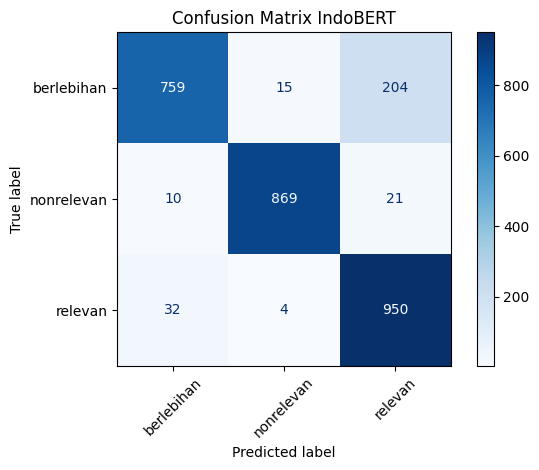

In [33]:
from transformers import BertForSequenceClassification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch
import pickle

# Load label encoder
with open("label_encoder_3.pkl", "rb") as f:
    label_encoder = pickle.load(f)

# === Load model IndoBERT dan bobotnya dari .pth ===
model = BertForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p2",
    num_labels=len(label_encoder.classes_)  # Harus sesuai jumlah kelas
)
model.load_state_dict(torch.load("model_relevansi_berita_3.pth"))  # Load bobot model
model.eval()

# Prediksi pada data test
with torch.no_grad():
    outputs = model(test_inputs, attention_mask=test_masks)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=1).cpu().numpy()

# Konversi label asli (encoded)
true_labels = test_labels.cpu().numpy()  # Jangan lupa ubah tensor ke numpy juga

# Decode ke string label
predicted_labels_decoded = label_encoder.inverse_transform(predictions)
true_labels_decoded = label_encoder.inverse_transform(true_labels)

# Confusion Matrix
cm = confusion_matrix(true_labels_decoded, predicted_labels_decoded, labels=label_encoder.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

# Tampilkan
plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix IndoBERT")
plt.tight_layout()
plt.show()


Confusion Matrix diatas merupakan hasil dari prediksi kelas final

## ROC-Curve

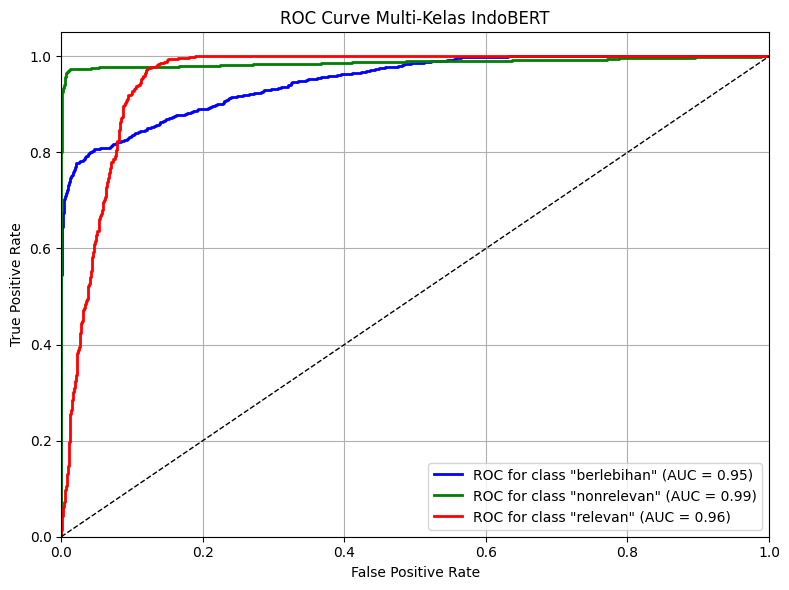

In [34]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Pastikan model dan label encoder sudah diload
model.eval()

# Dapatkan logits dari model
with torch.no_grad():
    outputs = model(test_inputs, attention_mask=test_masks)
    logits = outputs.logits.cpu().numpy()

# Konversi label menjadi bentuk biner (One-vs-Rest)
true_labels_bin = label_binarize(test_labels.cpu().numpy(), classes=list(range(len(label_encoder.classes_))))

# Hitung ROC Curve dan AUC untuk setiap kelas
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(label_encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve(true_labels_bin[:, i], logits[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot semua ROC Curve
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red']
for i, label_name in enumerate(label_encoder.classes_):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'ROC for class "{label_name}" (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)  # Garis random
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Multi-Kelas IndoBERT')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


Hasil ROC-Curve diatas menunjukkan hasil probabilitas bukan hasil final. Gambar diatas menunjukkan bahwa skor probabilitas model cukup "tajam" memisahkan antar kelas, meskipun argmax-nya kadang keliru. Maksud dari argmax adalah Dari semua kelas, skor saya paling tinggi di kelas ini, jadi ini prediksi saya!. 